<a href="https://colab.research.google.com/github/maellisrll-ui/Python-class-Session6-MiniProject/blob/main/Pokemon_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MINI PROJECT : From Public API to a Deployed Classification Dashboard :

Maellis RLL 🌺

4A DSBI

**In class, we saw the following process :**


1.   API Data : Collect data from a public API
2.   LLM Analysis : Analyze the data with a large language model (Claude)
3.   Visualisation : Visualise the results

0.   **Prerequisites & Setup**



In [72]:
#GitHub
  #My GitHub account is maellisrll-ui

#Git
!git --version
!git config --global user.name "Maellis"
!git config --global user.name "maellisrll@gmail.com"
!git clone https://github.com/maellisrll-ui/Python-class-Session6-MiniProject.git

#Editor : Jupyter
!jupyter --version
!jupyter install notebook jupyter

#Importing the libraries
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install requests
!pip install joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import joblib

#In class we saw also :
import os
import json
import random

git version 2.34.1
fatal: destination path 'Python-class-Session6-MiniProject' already exists and is not an empty directory.
Selected Jupyter core packages...
IPython          : 7.34.0
ipykernel        : 6.17.1
ipywidgets       : 7.7.1
jupyter_client   : 7.4.9
jupyter_core     : 5.9.1
jupyter_server   : 2.20.0
jupyterlab       : not installed
nbclient         : 0.10.4
nbconvert        : 7.17.1
nbformat         : 5.10.4
notebook         : 6.5.7
qtconsole        : not installed
traitlets        : 5.7.1
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir

---

1.   **Data Acquisistion**

*step 1 :*

[texte du lien](https://) I choose the first API : PokéAPI

In [13]:
POKEMON_URL = "https://pokeapi.co/api/v2/pokemon?limit=200"


*step 2 :*
*   What does one record look like? Which fields do you actually need?

      There are a lot of different pokemon listed on the main link, we see the name of the pokemon and the url. When I clicked on the url, there is a lot of additional information, like the abilities of the Pokemon through the different games (black, diamond, ...) and something about levels and leveling up.


*   Is the data paginated, or does one call return everything?

      When clicking on a specific pokemon's url, we have a lot of information, eveyhting is returned and give access to new urls.


*   Are there nested fields (e.g., a list of "types" or "stats") you'll need to flatten?

      I believe that I will need to flatten it because there is a lot of information,especially hundreds of line with levels and leveling up.

*step 3 :*

The pokemon I have chosen for the following part is squirtle  (because it is cute)
{"name":"squirtle","url":"https://pokeapi.co/api/v2/pokemon/7/"}

In [18]:
def fetch_all_records():
    records = []

    # TODO: loop through pages/offsets for your chosen API
    response = requests.get(POKEMON_URL)
    response.raise_for_status()
    data = response.json() # Correctly assign data
    pokemon_list = data.get('results', [])

    # TODO: for each item, extract the fields you need into a dict
    for pokemon in pokemon_list :
      detail = requests.get(pokemon['url']).json()
      stats = {stat['stat']['name']: stat['base_stat'] for stat in detail['stats']}
      types = [type['type']['name'] for type in detail['types']]

      # TODO: append each dict to `records`
      records.append({
          "name" : detail['name'],
          "abilities" : detail['abilities'],
          "height" : detail['height'],
          "weight" : detail['weight'],
          "stats" : stats,
          "types" : types,
          "attack" : stats.get('attack', None),
          "defense" : stats.get('defense', None),
          "hp" : stats.get('hp', None),
          "special-attack" : stats.get('special-attack', None),
          "special-defense" : stats.get('special-defense', None),
          "speed" : stats.get('speed', None)
          })

    return records


if __name__ == "__main__":
    records = fetch_all_records()
    df = pd.DataFrame(records)

    # Create 'data' directory if it doesn't exist
    os.makedirs('data', exist_ok=True)
    df.to_csv("data/raw_data.csv", index=False)
    print(f"Saved {len(df)} rows")

Saved 200 rows




---



2.   **EDA and Data Cleaning**

*step 1 :*


*   how many rows/columns ?

      There are 12 columns, 4 categorical and 8 numerical. And there are 200 rows.


*   which columns have missing values ?

      There are no missing values.


*   and whether you see obvious duplicates or garbage values ?

      There is no duplicated values.





In [19]:
df = pd.read_csv("data/raw_data.csv")
df.info()
df.describe()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   name             200 non-null    object
 1   abilities        200 non-null    object
 2   height           200 non-null    int64 
 3   weight           200 non-null    int64 
 4   stats            200 non-null    object
 5   types            200 non-null    object
 6   attack           200 non-null    int64 
 7   defense          200 non-null    int64 
 8   hp               200 non-null    int64 
 9   special-attack   200 non-null    int64 
 10  special-defense  200 non-null    int64 
 11  speed            200 non-null    int64 
dtypes: int64(8), object(4)
memory usage: 18.9+ KB


np.int64(0)

*step 2 :*

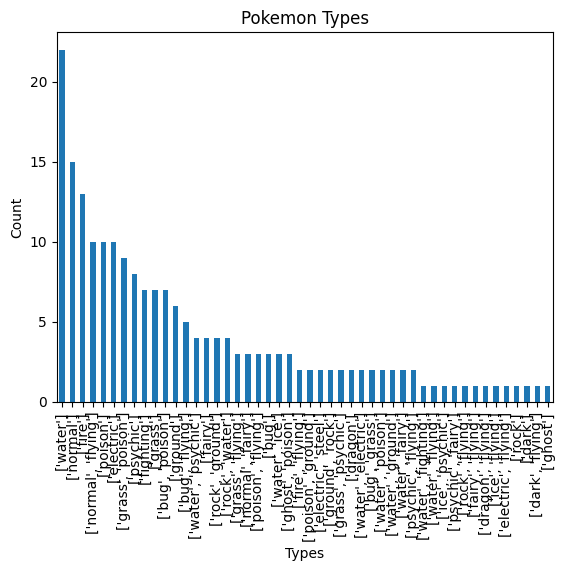

In [21]:
df["types"].value_counts().plot(kind='bar')
plt.title("Pokemon Types")
plt.xlabel("Types")
plt.ylabel("Count")
plt.show()

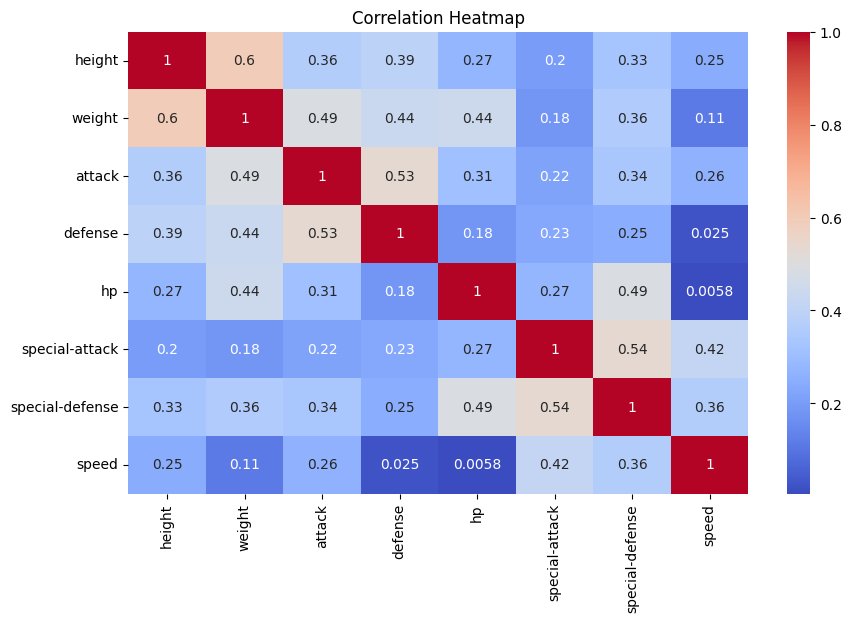

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

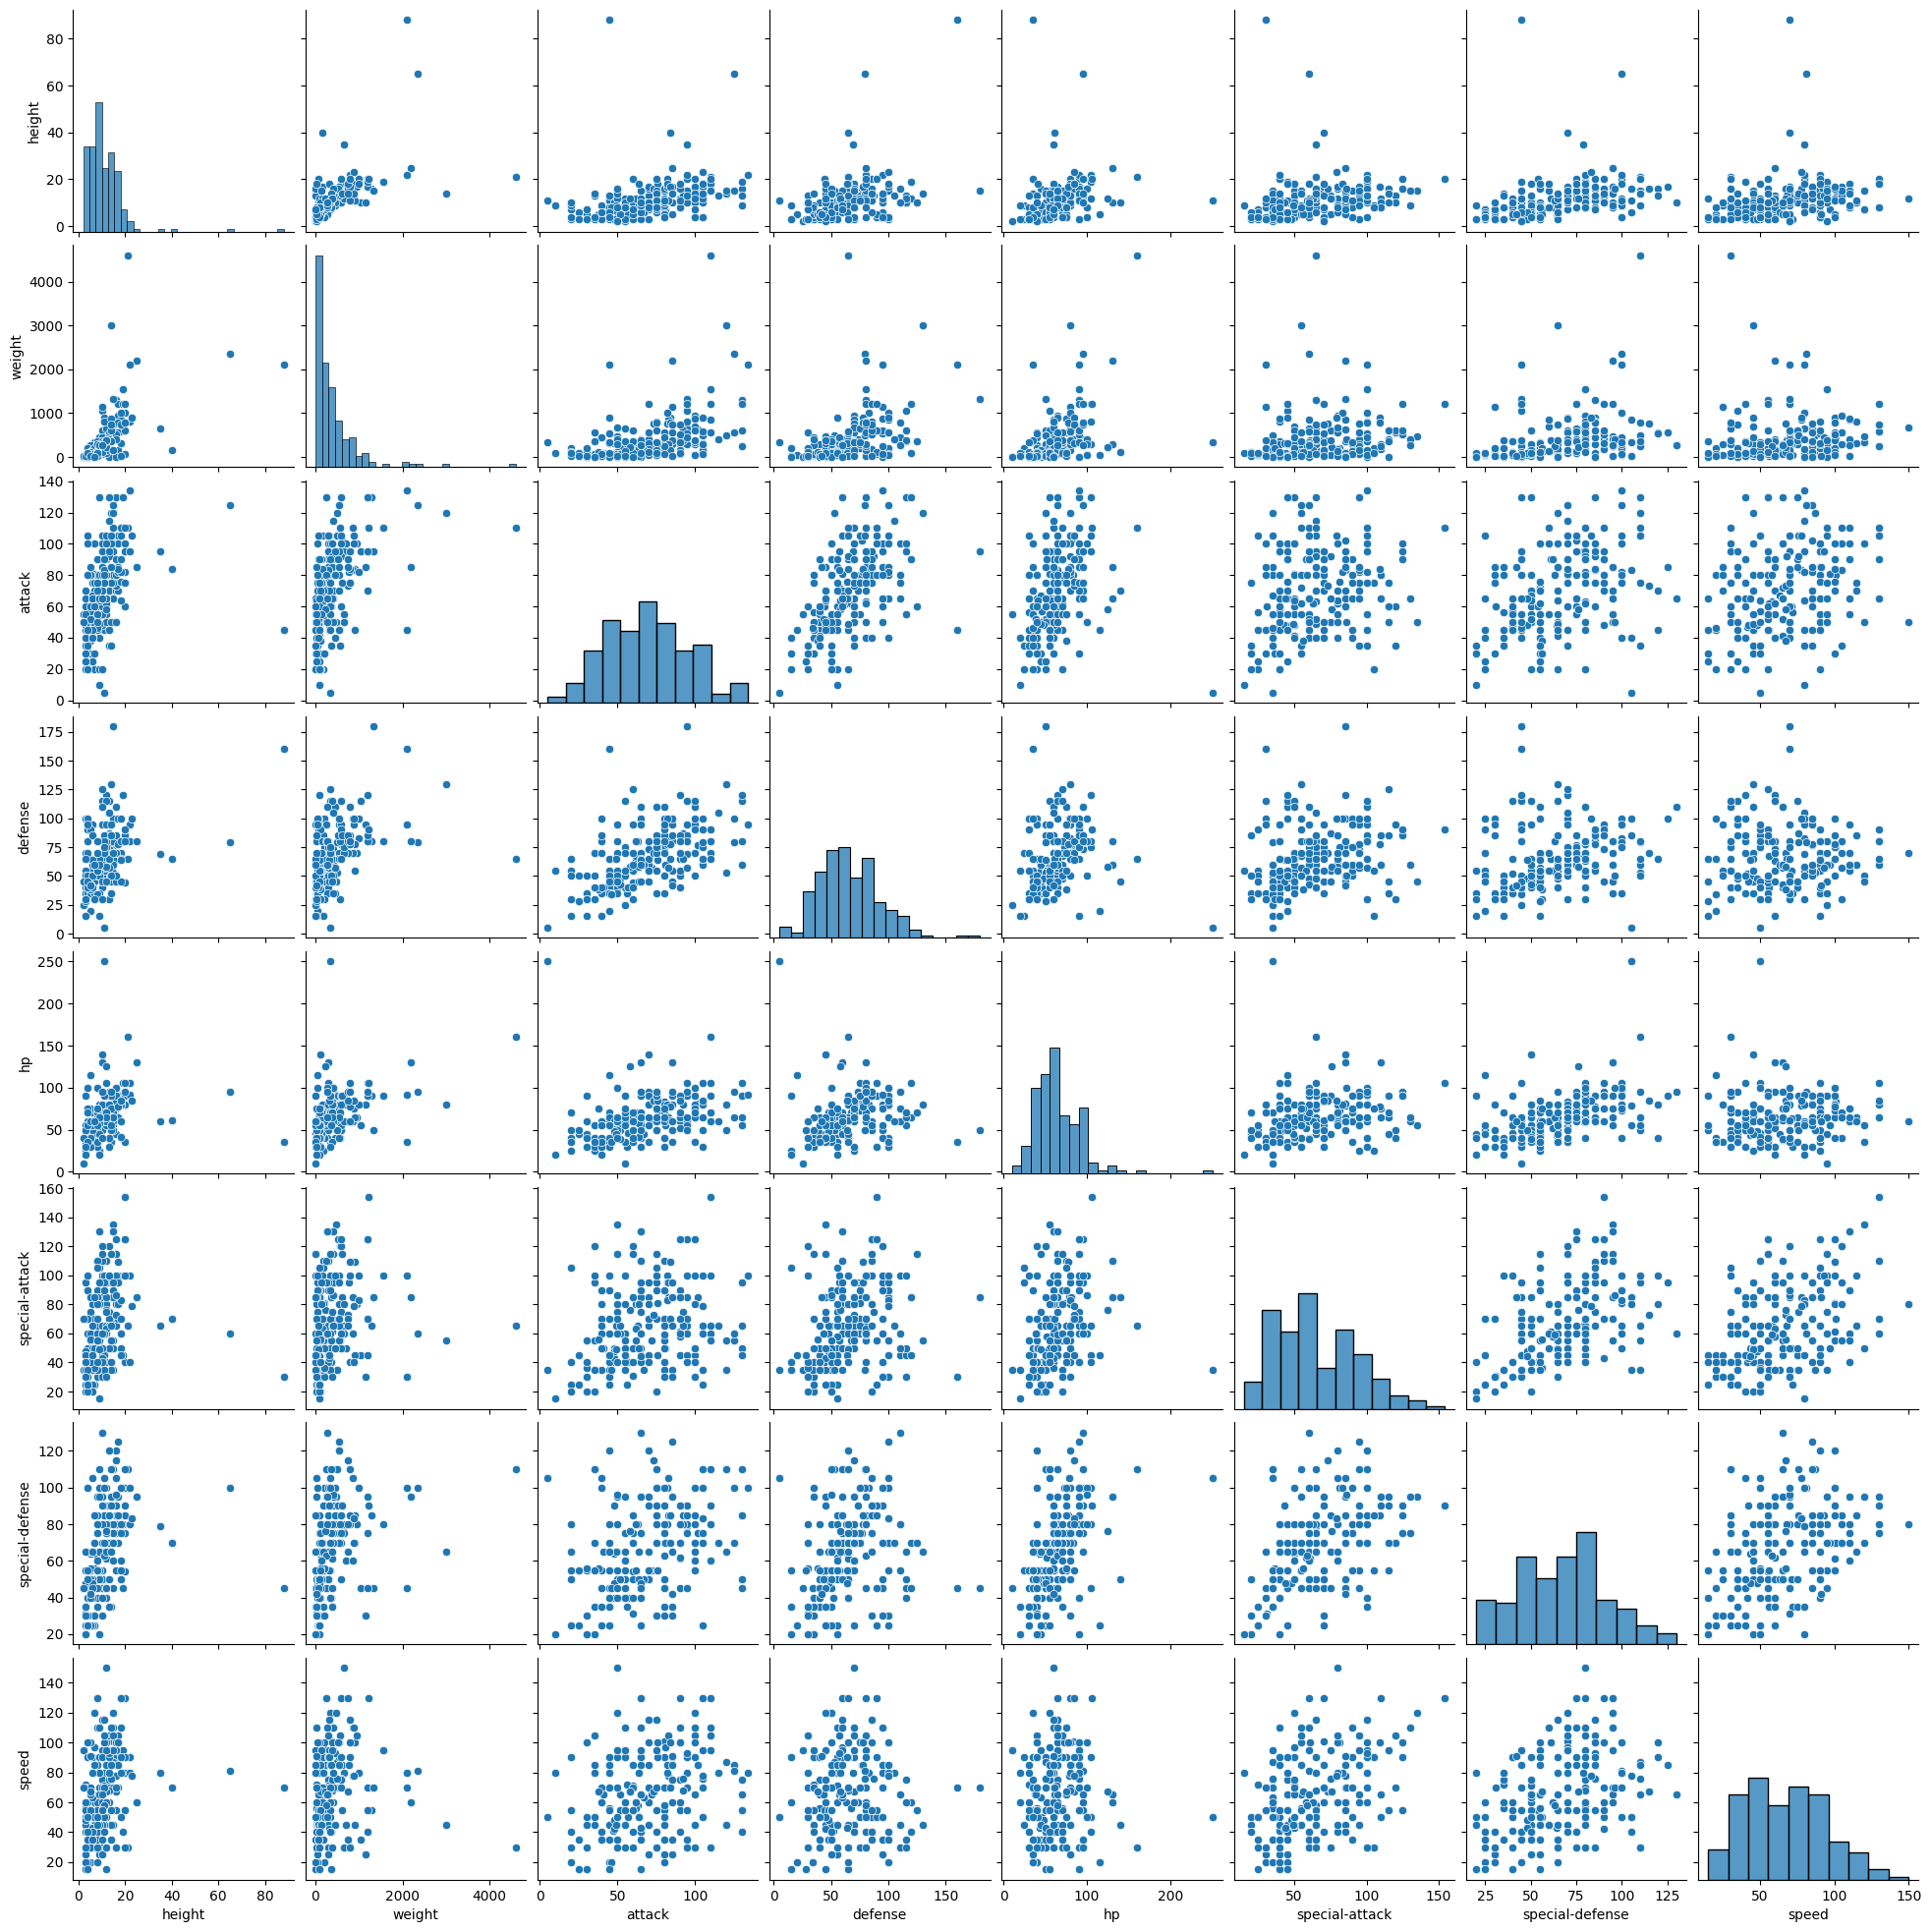

In [31]:
sns.pairplot(df)
plt.show()

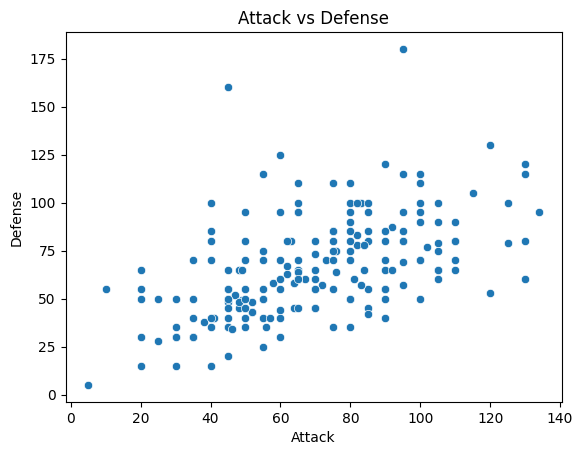

In [26]:
sns.scatterplot(data=df, x='attack', y='defense')
plt.title("Attack vs Defense")
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.show()

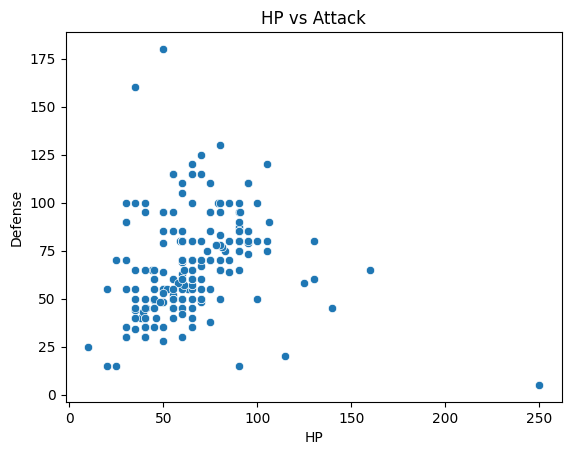

In [30]:
sns.scatterplot(data=df, x='hp', y='defense')
plt.title("HP vs Attack")
plt.xlabel("HP")
plt.ylabel("Defense")
plt.show()

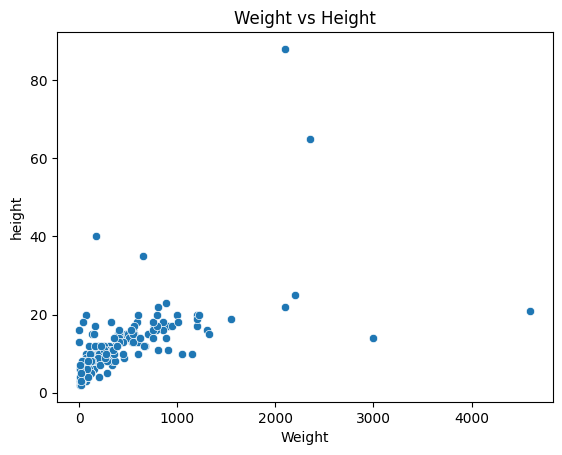

In [29]:
sns.scatterplot(data=df, x='weight', y='height')
plt.title("Weight vs Height")
plt.xlabel("Weight")
plt.ylabel("height")
plt.show()

*step 3 :*



*   **Missing target values :** There are no missing target values.
*   **Missing feature values :** There are no missing feature values.
*   **Duplicates :** There are no outliers
*   **Rare classes :** In the barchart, I saw that there are some unique classes, with only 1 pokemon. I think I should merge them with their identical style (for example, "water'ground'" type should be merged with water. In this way, the data will be more representative and easier to analyse and understand.


In [41]:
df["primary_type"] = df["types"].apply(lambda x: x[0])

type_counts = df["primary_type"].value_counts()

treshold = 3

df["type_clean"] = df["primary_type"].apply(
    lambda x: x if type_counts[x] >= treshold else "other"
)

print(df["type_clean"].value_counts())

type_clean
water       39
normal      28
grass       21
bug         17
fire        15
poison      15
electric    13
psychic     11
rock        10
ground       8
fighting     7
fairy        5
ghost        4
other        4
dragon       3
Name: count, dtype: int64


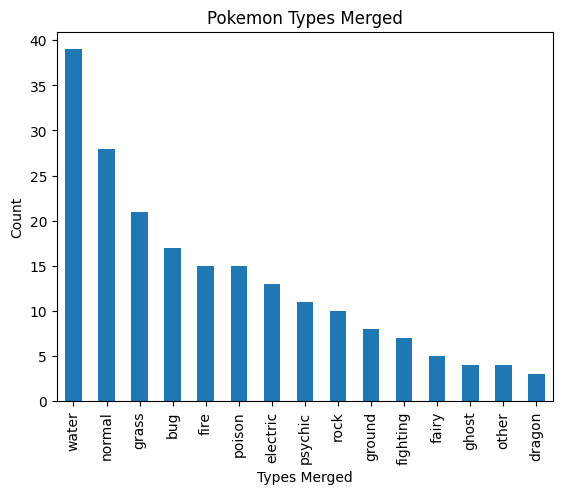

In [42]:
df["type_clean"].value_counts().plot(kind='bar')
plt.title("Pokemon Types Merged")
plt.xlabel("Types Merged")
plt.ylabel("Count")
plt.show()

*step 4 :*

In [44]:
os.makedirs('data', exist_ok=True)
df_clean = df.copy()
df_clean.to_csv("data/clean_data.csv", index=False)






---



3.   **Classification Model**

*step 1 :*

In [46]:
from sklearn.preprocessing import LabelEncoder

# your chosen numeric feature columns
FEATURES = ["attack", "special-attack", "defense", "special-defense", "hp", "speed", "height", "weight"]

# your target column name
TARGET = "type_clean"


X = df[FEATURES]
y = df[TARGET]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features shape:", X.shape)
print("Target classes:", le.classes_)

Features shape: (200, 8)
Target classes: ['bug' 'dragon' 'electric' 'fairy' 'fighting' 'fire' 'ghost' 'grass'
 'ground' 'normal' 'other' 'poison' 'psychic' 'rock' 'water']


*step 2 :*

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

Train set: (160, 8)
Test set: (40, 8)


*step 3 :*

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

*step 4 :*

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "random_forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
}

*step 5 :*

In [63]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix


results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average="macro", zero_division=0)

    print(name, acc, prec, rec, f1)


    # I prefer to show the results in a table for visibility purpose. I will use the .append() method to add the dictionanry to the list

    results.append({
        "Model": name,
        "Accuracy Score": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1 Score": round(f1, 3),
    })

results_df = pd.DataFrame(results)
display(results_df)

logistic_regression 0.35 0.28767676767676764 0.33666666666666667 0.30620439988861037
random_forest 0.275 0.19829059829059828 0.2033333333333333 0.18089947089947087


,Model,Accuracy Score,Precision,Recall,F1 Score
0,logistic_regression,0.350,0.288,0.337,0.306
1,random_forest,0.275,0.198,0.203,0.181


In [69]:
# Identify the best model based on Accuracy Score
best_model_name = results_df.loc[results_df['Accuracy Score'].idxmax()]['Model']
best_model = models[best_model_name]

# Generate predictions using the best model
best_preds = best_model.predict(X_test_scaled)

print(f"Best Model : {best_model_name}")


#confusion matrix :
cm = confusion_matrix(y_test, best_preds, labels=range(len(le.classes_)))

Best Model : logistic_regression


*step 6:*

In [73]:
joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

# Calculate feature importances based on the best model type
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_.tolist()
elif hasattr(best_model, 'coef_'):

    if best_model.coef_.ndim > 1:
        importances = np.mean(np.abs(best_model.coef_), axis=0).tolist()
    else:
        importances = np.abs(best_model.coef_).tolist()
else:
    importances = []


with open("model_metrics.json", "w") as f:
    json.dump({
        "all_model_results": results,
        "best_model": best_model_name,
        "confusion_matrix": cm.tolist(),
        "class_labels": le.classes_.tolist(),
        "feature_importance": importances,
        "features": FEATURES,
    }, f, indent=2)



---



4.   **Streamlit Dashboard**

*step 1 :*